# Búsqueda en Profundidad (DFS) y en Anchura (BFS)

## 1. Formulación del problema

In [1]:
from collections import deque

class Problem:
    """Clase base: los 5 componentes de un problema de búsqueda."""
    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        raise NotImplementedError

    def result(self, state, action):
        raise NotImplementedError

    def is_goal(self, state):
        return state == self.goal

    def action_cost(self, state1, action, state2):
        return 1

class GraphProblem(Problem):
    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return list(self.graph[state].keys())

    def result(self, state, action):
        return action

    def action_cost(self, state1, action, state2):
        return self.graph[state1][state2]

## 2. Nodo de búsqueda
El **nodo** envuelve a un estado y añade el libro de registro: padre, acción y costo acumulado.

In [2]:
class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action if action else state
        self.path_cost = path_cost

    def __repr__(self):
        return f"<Node state:{self.state}, parent:{self.parent}, action:{self.action}, path_cost:{self.path_cost}>"

    def solution(self):
        return " -> ".join([node.action for node in self.path()])

    def path(self):
        node, path_back = self, []
        while node:
            path_back.append(node)
            node = node.parent
        return list(reversed(path_back))

    def expand(self, problem):
        return [self.child_node(problem, action) for action in problem.actions(self.state)]

    def child_node(self, problem, action):
        next_state = problem.result(self.state, action)
        step_cost = problem.action_cost(self.state, action, next_state)
        return Node(next_state, self, action, self.path_cost + step_cost)

## 3. Los dos algoritmos

Ambos comparten el mismo esqueleto: extraer de la frontera, comprobar meta, expandir y volcar los hijos. Solo cambia la **política de extracción** (`pop()` LIFO vs. `popleft()` FIFO).

In [3]:
def depth_first_graph_search(problem):
    """DFS: frontera = pila (LIFO), explora el nodo más profundo primero."""
    start_node = Node(problem.initial)
    if problem.is_goal(start_node.state):
        return start_node

    frontier = [start_node]
    explored = set()
    frontier_states = {start_node.state}

    while frontier:
        # Tomamos la opción más reciente (LIFO)
        node = frontier.pop()
        frontier_states.remove(node.state)

        # Marcamos el estado como visitado para no regresar
        explored.add(node.state)

        # Si es la meta, ¡terminamos!
        if problem.is_goal(node.state):
            return node

        # Generamos los siguientes pasos
        for child in node.expand(problem):
            if child.state not in explored and child.state not in frontier_states:
                frontier.append(child)
                frontier_states.add(child.state)

    return None # No se encontró solución

## 4. Ejemplo concreto: el mapa de Rumania (AIMA)
Viajar de **Arad** a **Bucarest**.

In [4]:
romania = {
    'Arad':      {'Zerind': 75, 'Sibiu': 140, 'Timisoara': 118},
    'Zerind':    {'Arad': 75, 'Oradea': 71},
    'Oradea':    {'Zerind': 71, 'Sibiu': 151},
    'Sibiu':     {'Arad': 140, 'Oradea': 151, 'Fagaras': 99, 'Rimnicu Vilcea': 80},
    'Timisoara': {'Arad': 118, 'Lugoj': 111},
    'Lugoj':     {'Timisoara': 111, 'Mehadia': 70},
    'Mehadia':   {'Lugoj': 70, 'Dobreta': 75},
    'Dobreta':   {'Mehadia': 75, 'Craiova': 120},
    'Craiova':   {'Dobreta': 120, 'Rimnicu Vilcea': 146, 'Pitesti': 138},
    'Rimnicu Vilcea': {'Sibiu': 80, 'Craiova': 146, 'Pitesti': 97},
    'Fagaras':   {'Sibiu': 99, 'Bucarest': 211},
    'Pitesti':   {'Rimnicu Vilcea': 97, 'Craiova': 138, 'Bucarest': 101},
    'Bucarest':  {'Fagaras': 211, 'Pitesti': 101, 'Giurgiu': 90, 'Urziceni': 85},
    'Giurgiu':   {'Bucarest': 90},
    'Urziceni':  {'Bucarest': 85, 'Hirsova': 98, 'Vaslui': 142},
    'Hirsova':   {'Urziceni': 98, 'Eforie': 86},
    'Eforie':    {'Hirsova': 86},
    'Vaslui':    {'Urziceni': 142, 'Iasi': 92},
    'Iasi':      {'Vaslui': 92, 'Neamt': 87},
    'Neamt':     {'Iasi': 87},
}

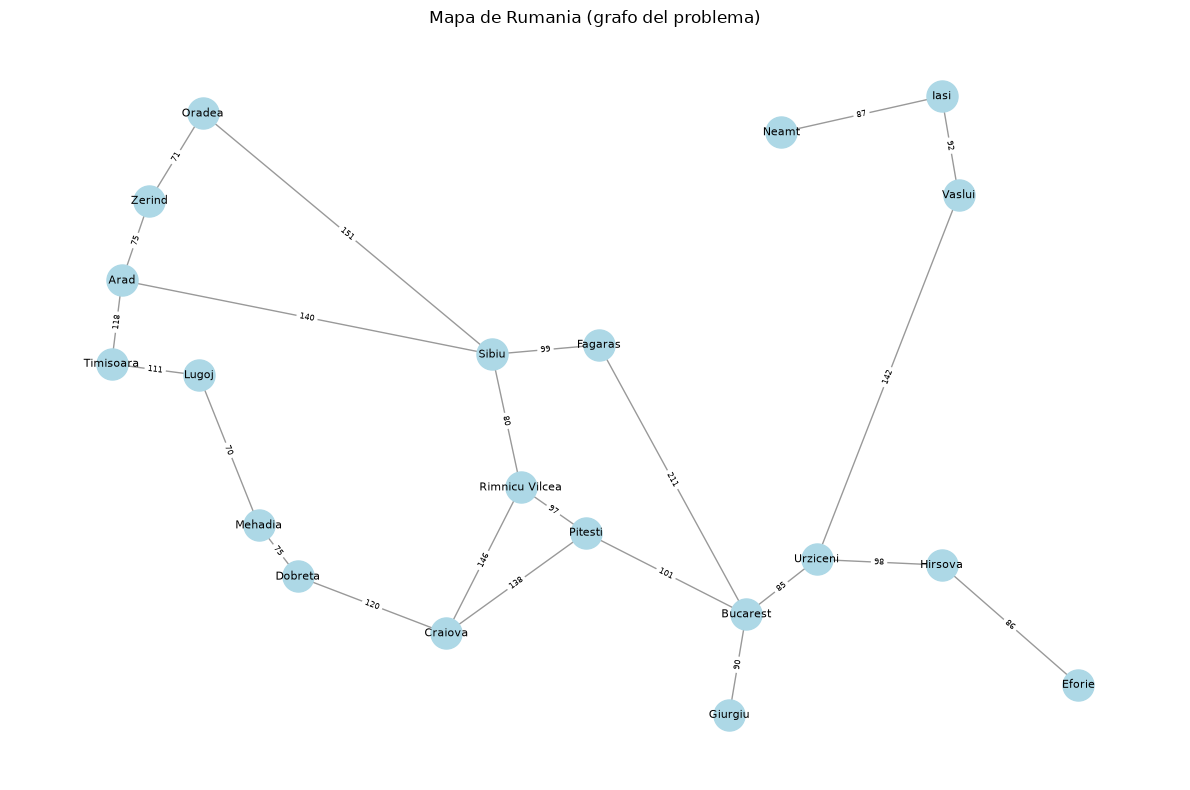

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()
for city, neighbors in romania.items():
    for nb, cost in neighbors.items():
        G.add_edge(city, nb, weight=cost)

pos = {
    'Oradea': (21.93, 47.07), 'Zerind': (21.52, 46.61), 'Arad': (21.31, 46.19),
    'Timisoara': (21.23, 45.75), 'Lugoj': (21.90, 45.69), 'Mehadia': (22.36, 44.90),
    'Dobreta': (22.66, 44.63), 'Craiova': (23.80, 44.33), 'Sibiu': (24.15, 45.80),
    'Rimnicu Vilcea': (24.37, 45.10), 'Pitesti': (24.87, 44.86), 'Fagaras': (24.97, 45.85),
    'Bucarest': (26.10, 44.43), 'Giurgiu': (25.97, 43.90), 'Urziceni': (26.64, 44.72),
    'Hirsova': (27.60, 44.69), 'Eforie': (28.65, 44.06), 'Vaslui': (27.73, 46.64),
    'Iasi': (27.60, 47.16), 'Neamt': (26.37, 46.97),
}

plt.figure(figsize=(12, 8))
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'), font_size=6)
plt.title('Mapa de Rumania (grafo del problema)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
def depth_first_graph_search(problem):
    """DFS: frontera = pila (LIFO), explora el nodo más profundo primero."""
    frontier = [Node(problem.initial)]
    explored = set()

    while frontier:
        node = frontier.pop()  # LIFO
        if problem.is_goal(node.state):
            return node
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                frontier.append(child)
    return None

In [7]:
problem = GraphProblem('Arad', 'Bucarest', romania)
node_dfs = depth_first_graph_search(problem)
node_dfs.solution()

'Arad -> Timisoara -> Lugoj -> Mehadia -> Dobreta -> Craiova -> Pitesti -> Bucarest'

## 5. Comparación de resultados

In [8]:
print(f"DFS: {len(node_dfs.path())-1} pasos, {node_dfs.path_cost} km")

DFS: 7 pasos, 733 km


In [9]:
import matplotlib.animation as animation
from IPython.display import HTML

def trace_search(problem, fifo=True):
    frontier = [Node(problem.initial)]
    explored = set()
    tree_edges = []
    steps = []

    while frontier:
        node = frontier.pop(0) if fifo else frontier.pop()
        if problem.is_goal(node.state):
            steps.append({'current': node.state, 'frontier': [n.state for n in frontier],
                          'explored': set(explored), 'tree': list(tree_edges), 'done': True})
            return node, steps
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                frontier.append(child)
                tree_edges.append((node.state, child.state))
        steps.append({'current': node.state, 'frontier': [n.state for n in frontier],
                      'explored': set(explored), 'tree': list(tree_edges), 'done': False})
    return None, steps


def animate_search(problem, steps, color):
    fig, ax = plt.subplots(figsize=(12, 8))

    def draw(frame):
        ax.clear()
        step = steps[frame]
        frontier, explored, tree = step['frontier'], step['explored'], step['tree']
        current = step['current']

        nx.draw_networkx_edges(G, pos, alpha=0.12, ax=ax)
        nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=400, ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

        if tree:
            nx.draw_networkx_edges(G, pos, edgelist=tree, edge_color=color, width=2.5, ax=ax)
        if explored:
            nx.draw_networkx_nodes(G, pos, nodelist=list(explored), node_color='lightgreen', node_size=400, ax=ax)
        if frontier:
            nx.draw_networkx_nodes(G, pos, nodelist=frontier, node_color='orange', node_size=400, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[problem.goal], node_color='gold', node_size=550, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[current], node_color=color, node_size=600, ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

        ax.text(0.5, 1.02, f"Frontera: {frontier}", transform=ax.transAxes, ha='center', fontsize=9)
        ax.axis('off')

    anim = animation.FuncAnimation(fig, draw, frames=len(steps), interval=750, repeat=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [10]:
dfs_node_t, dfs_steps = trace_search(problem, fifo=False)
animate_search(problem, dfs_steps, 'crimson')

In [11]:
bfs_node_t, bfs_steps = trace_search(problem, fifo=True)
animate_search(problem, bfs_steps, 'royalblue')